Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6090 - loss: 0.6669 - val_accuracy: 0.7886 - val_loss: 0.5870
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7210 - loss: 0.5794 - val_accuracy: 0.7967 - val_loss: 0.5171
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7434 - loss: 0.5258 - val_accuracy: 0.7967 - val_loss: 0.4808
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7576 - loss: 0.4974 - val_accuracy: 0.7886 - val_loss: 0.4658
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7821 - loss: 0.4699 - val_accuracy: 0.7886 - val_loss: 0.4628
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7536 - loss: 0.4723 - val_accuracy: 0.8049 - val_loss: 0.4645
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7739 - loss: 0.4590 - val_accuracy: 0.8049 - val_loss: 0.4673
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7719 - loss: 0.4548 - val_accuracy: 0.7967 - val_lo

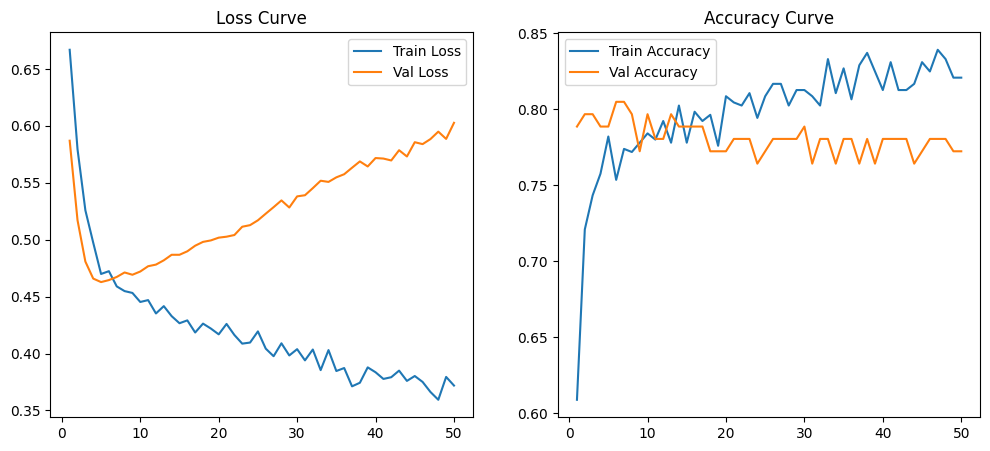


[Classification Report]
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       107
           1       0.67      0.62      0.64        47

    accuracy                           0.79       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.79      0.79      0.79       154


[Confusion Matrix]


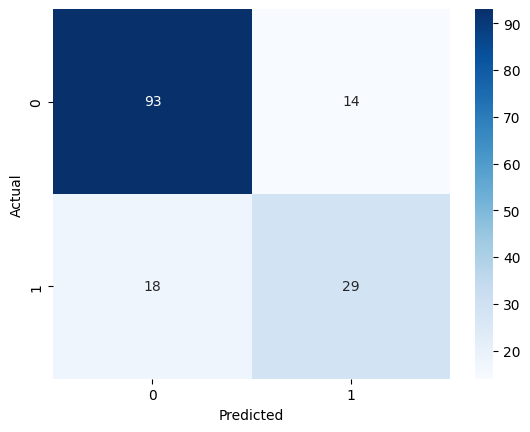

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models, Input

# 1. 데이터 로드 및 전처리
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/diabetes.csv')
df.columns = df.columns.str.strip()

y = df['Outcome']
X = df.drop('Outcome', axis=1)

# 2. 데이터 분할
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 3. 데이터 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 4. 모델 구축 (이진 분류용)
model = models.Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid") # 0~1 사이의 확률을 출력
])

# 5. 모델 컴파일 (중요: 분류용 손실함수와 지표로 변경)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy", # [수정] mse -> binary_crossentropy
    metrics=["accuracy"]         # [수정] mae -> accuracy (이제 에러가 나지 않습니다!)
)

# 6. 모델 학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

# 7. 예측 및 결과 분석
y_pred = model.predict(X_test)
y_pred_class = (y_pred > 0.5).astype(int)

# 8. 시각화 (이제 history['accuracy']를 정상적으로 사용할 수 있습니다)
epochs_range = range(1, len(history.history['loss']) + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['loss'], label='Train Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['accuracy'], label='Train Accuracy') # 정상 작동
plt.plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy') # 정상 작동
plt.title('Accuracy Curve'); plt.legend()
plt.show()

# 9. 최종 리포트 (분류용)
print("\n[Classification Report]")
print(classification_report(y_test, y_pred_class))

print("\n[Confusion Matrix]")
cm = confusion_matrix(y_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱근오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test))

평균제곱근오차 0.14370648838141722
평균제곱근오차 0.14370648838141722
평균제곱근오차 0.14370648838141717


In [8]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

dy_preds = model.predict(X_test)
print('평균제곱근오차', mean_squared_error(dy_preds, y_test))

평균제곱근오차 0.22727272727272727


In [9]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

ry_preds = model.predict(X_test)
print('평균제곱근오차', mean_squared_error(ry_preds, y_test))

평균제곱근오차 0.13915584415584414


In [10]:
from sklearn.svm import SVR

model = SVR(kernel='linear')
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error

ry_preds = model.predict(X_test)
print('평균제곱근오차', mean_squared_error(ry_preds, y_test))

평균제곱근오차 0.14448869986363236


In [15]:

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression MSE:", mean_squared_error(y_test, pred_lr))

Linear Regression MSE: 0.17104527280850101


Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2330 - mae: 0.3698 - val_loss: 0.1831 - val_mae: 0.3393
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1667 - mae: 0.3203 - val_loss: 0.1717 - val_mae: 0.3291
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1531 - mae: 0.3106 - val_loss: 0.1632 - val_mae: 0.3183
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1463 - mae: 0.2972 - val_loss: 0.1595 - val_mae: 0.3256
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1418 - mae: 0.2997 - val_loss: 0.1620 - val_mae: 0.3145
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1374 - mae: 0.2886 - val_loss: 0.1546 - val_mae: 0.3175
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1341 - mae: 0.2871 - val_loss: 0.1560 - val_mae: 0.3095
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1304 - mae: 0.2807 - val_loss: 0.1549 - val_mae: 0.3135
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1283 - mae: 

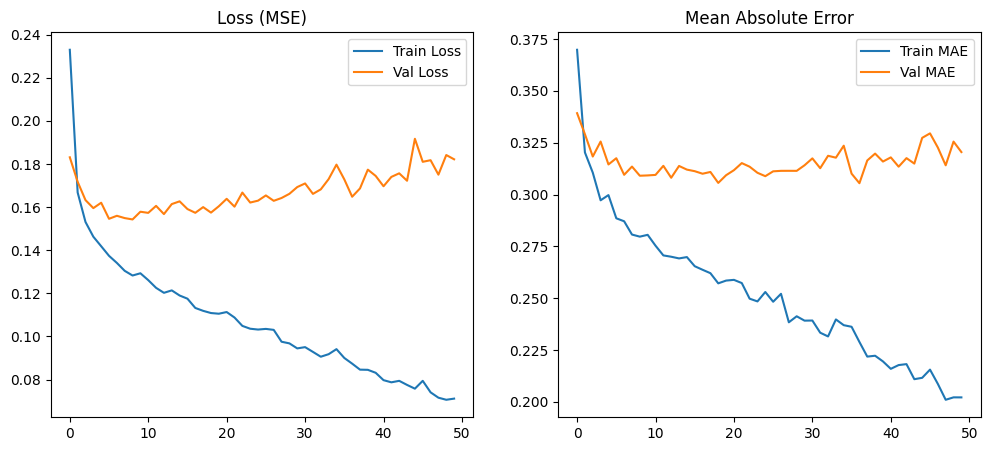


평균 절대 오차(MAE): 0.3790
결정 계수(R2 Score): -0.0998


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras import layers, models, Input

# 1. 데이터 로드 및 전처리
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/diabetes.csv') # 파일 경로 확인!


y = df['Outcome']
X = df.drop('Outcome', axis=1)

# 2. 데이터 분할
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 데이터 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 4. 모델 구축 (회귀용 구조)
model = models.Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    # [중요] 회귀의 출력층은 노드가 1개이며 활성화 함수를 쓰지 않거나 'linear'를 씁니다.
    layers.Dense(1)
])

# 5. 모델 컴파일 (회귀용 손실함수와 지표)
model.compile(
    optimizer="adam",
    loss="mse",        # Mean Squared Error (평균제곱오차)
    metrics=["mae"]    # Mean Absolute Error (평균절대오차) - 'accuracy'를 쓰면 에러 납니다!
)

# 6. 모델 학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

# 7. 예측 및 결과 분석
y_pred = model.predict(X_test).flatten()

# 8. 시각화 (Loss & MAE)
plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (MSE)'); plt.legend()

# MAE 그래프 (정확도 대신 오차를 봅니다)
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Mean Absolute Error'); plt.legend()
plt.show()

# 9. 최종 리포트
print(f"\n평균 절대 오차(MAE): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"결정 계수(R2 Score): {r2_score(y_test, y_pred):.4f}")